# Inference: picture in, posed 3D body out

Loads `checkpoint.pt` from `train.ipynb` and runs it on clips the network never
saw. Three views of the same answer:

1. the **crop**, with the predicted and true skeletons drawn on it
2. the **photograph**, with the posed MHR body drawn back into it
3. the **3D scene**, with the camera at the origin -- the body sits exactly as
   far away, and as far to one side, as the real person did

Nothing here reads the cache. It decodes a video frame, cuts out a crop, and runs
the network -- the same path a real picture would take.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import plotly.graph_objects as go
import torch

HERE = pathlib.Path.cwd()
if HERE.name != "mhr_pose_net":
    HERE = HERE / "mhr_pose_net"
sys.path.insert(0, str(HERE))

import data
import model
import analytic_ik as ik
import mhr_scene
from mhr_kit import render
from mhr_kit.model import faces

rig = ik.Rig(level_of_detail=4)          # LOD 4: a mesh worth looking at, still light
body = model.Body(rig)
triangles = np.asarray(faces(rig.model))

saved = torch.load(HERE / "checkpoint.pt", map_location="cpu", weights_only=False)
net = model.PoseNet(saved["backbone"], pretrained=False)
net.load_state_dict(saved["weights"])
net.eval()

BONES = [("pelvis", "neck"), ("neck", "head"), ("head", "head_top"),
         ("neck", "left_shoulder"), ("left_shoulder", "left_elbow"),
         ("left_elbow", "left_wrist"),
         ("neck", "right_shoulder"), ("right_shoulder", "right_elbow"),
         ("right_elbow", "right_wrist"),
         ("pelvis", "left_hip"), ("left_hip", "left_knee"), ("left_knee", "left_ankle"),
         ("pelvis", "right_hip"), ("right_hip", "right_knee"), ("right_knee", "right_ankle")]
LINKS = [(data.KEYPOINTS.index(a), data.KEYPOINTS.index(b)) for a, b in BONES]

print(saved["backbone"], "loaded")

resnet18 loaded


## 1. Pick a frame the network has not seen

The person box would come from a detector in real use. Here it comes from the
ground-truth keypoints, which is what ASPset's own `boxes` files contain -- so
the box is honest about the person's place in the frame, but it is not something
the network worked out for itself.

In [2]:
CLIP = None      # None picks the first held-back clip; or e.g. "1e28-0028-right"
FRAME = 120

_, val_clips = data.split_clips(every=6)
clip = [c for c in data.clips() if c.name == (CLIP or val_clips[0])][0]

intrinsics, rotation, translation = data.read_camera(clip.camera)
all_joints = data.read_joints(clip.joints)
FRAME = min(FRAME, len(all_joints) - 1)

photo = data.read_frame(clip.video, FRAME)
targets = data.viewer_targets(all_joints[FRAME], rotation, translation)
truth = np.array([targets[name] for name in data.KEYPOINTS])

box = data.person_box(data.project(truth, intrinsics))
batch = data.make_batch(photo, box, intrinsics)
prediction = model.predict(net, body, batch)

joints = prediction["joints"][0].numpy()
print(f"{clip.name}  frame {FRAME}")
print(f"  distance      predicted {-joints[data.PELVIS][2] / 100:5.2f} m"
      f"   true {-truth[data.PELVIS][2] / 100:5.2f} m")
print(f"  joint error   {np.linalg.norm(joints - joints[data.PELVIS] - (truth - truth[data.PELVIS]), axis=1).mean() * 10:.0f} mm")

1e28-0001-left  frame 120
  distance      predicted 18.64 m   true 17.85 m
  joint error   112 mm


## 2. The crop, with both skeletons on it

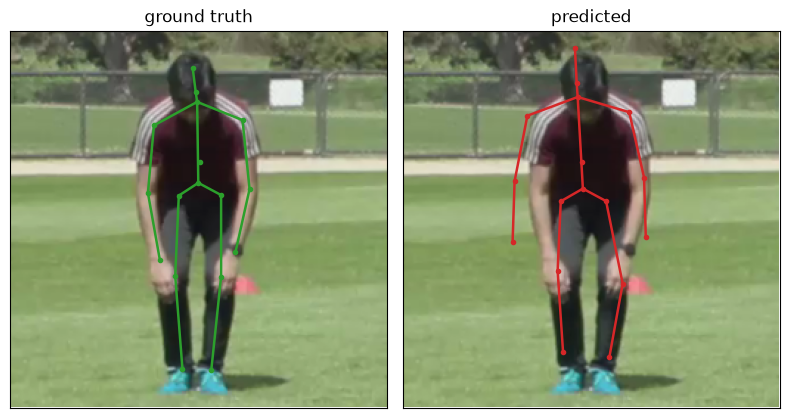

In [3]:
def to_crop_pixels(points_3d, box, intrinsics, pixels=256):
    """Viewer-frame points -> pixel positions inside the crop."""
    return (data.project(points_3d, intrinsics) - box[:2]) / (box[2] / 2) * (pixels / 2) + pixels / 2


crop = (batch["image"][0].numpy().transpose(1, 2, 0) * data.IMAGENET_STD
        + data.IMAGENET_MEAN).clip(0, 1)

figure, axes = plt.subplots(1, 2, figsize=(8, 4.2))
for ax, points, colour, title in ((axes[0], truth, "tab:green", "ground truth"),
                                  (axes[1], joints, "tab:red", "predicted")):
    uv = to_crop_pixels(points, box, intrinsics)
    ax.imshow(crop)
    for a, b in LINKS:
        ax.plot(uv[[a, b], 0], uv[[a, b], 1], "-", color=colour, lw=1.8)
    ax.scatter(uv[:, 0], uv[:, 1], s=9, color=colour)
    ax.set(title=title, xticks=[], yticks=[], xlim=(0, 256), ylim=(256, 0))
plt.tight_layout()
plt.show()

## 3. The body, drawn back into the photograph

`pose_vector` turns the prediction into the 204-number vector MHR takes -- this
is the only place euler angles appear -- and the rig produces a mesh. The camera
sits at the origin looking along -z, which is exactly where the real camera was,
so nothing has to be lined up by hand.

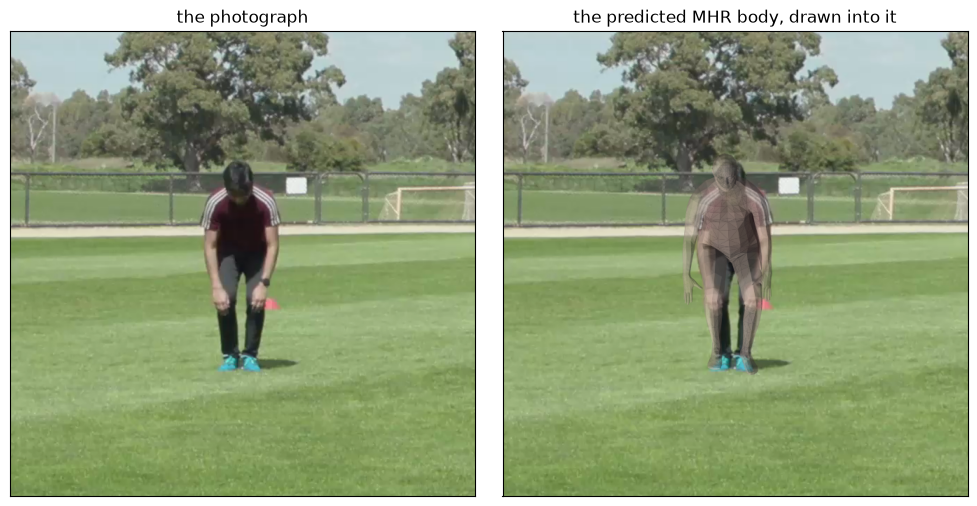

In [4]:
pose = model.pose_vector(rig, prediction["angles"][0], prediction["scales"][0],
                         prediction["rotation"][0], prediction["translation"][0])
mesh = ik.mesh_from_pose(rig, pose)

camera = render.Camera(focal=float(intrinsics[0]),
                       center=(float(intrinsics[2]), float(intrinsics[3])),
                       size=(photo.shape[1], photo.shape[0]),
                       rotation=np.diag([1.0, -1.0, -1.0]), translation=np.zeros(3))
overlay = render.render(mesh, triangles, camera, background=photo, alpha=0.6)

figure, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(photo)
axes[0].set(title="the photograph")
axes[1].imshow(overlay)
axes[1].set(title="the predicted MHR body, drawn into it")
for ax in axes:                     # zoom both onto the person
    ax.set(xlim=(box[0] - box[2], box[0] + box[2]),
           ylim=(box[1] + box[2], box[1] - box[2]), xticks=[], yticks=[])
plt.tight_layout()
plt.show()

## 4. The 3D scene

The camera is at the origin. The body is out at its real distance, turned the way
the real person was turned. Drag to rotate: the point of this view is that the
answer is a body *somewhere*, not a floating pose.

The red dot is the body's left hand and the blue one its right. If they look
swapped compared with the photograph above, the scene is mirrored -- the one
mistake in this kind of plot that stays invisible otherwise.

In [5]:
figure = mhr_scene.scene_figure([mesh], triangles, names=["predicted"],
                                title=f"{clip.name} frame {FRAME} - "
                                      f"{mhr_scene.describe(rig, pose)}",
                                rig=rig, poses=[pose])

drawn = mhr_scene.plotted(truth)
for a, b in LINKS:
    figure.add_trace(go.Scatter3d(x=drawn[[a, b], 0], y=drawn[[a, b], 1], z=drawn[[a, b], 2],
                                  mode="lines", line=dict(color="green", width=4),
                                  name="ground truth", legendgroup="truth",
                                  showlegend=(a, b) == LINKS[0], hoverinfo="skip"))
figure.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], mode="markers+text",
                              marker=dict(size=6, color="black", symbol="diamond"),
                              text=["camera"], textposition="top center",
                              name="camera", hoverinfo="skip"))
figure.show()

## 5. Scores over every held-back frame

`mpjpe_mm` is the average distance between a predicted joint and the real one,
after both are moved to sit on the same hips. `pixel_error` is measured in the
original 4K photograph. The *floor* row is the same measurement applied to the
ground-truth labels themselves: the analytic solver aims MHR's joint centres at
ASPset's skin markers, and those disagree by a few centimetres whatever anyone
does.

In [6]:
import collections

from torch.utils.data import DataLoader

val_data = data.PoseData(val_clips, augment=False)
val_loader = DataLoader(val_data, batch_size=24)

totals, floors, seen = collections.Counter(), collections.Counter(), 0
for batch in val_loader:
    prediction = model.predict(net, body, batch)
    truth_as_prediction = dict(
        angles=batch["angles"], scales=batch["scales"], rotation=batch["root_rot"],
        camera=model.camera_target(batch["joints"][:, data.PELVIS],
                                   batch["box"], batch["intrinsics"]))
    count = len(batch["image"])
    totals.update({k: v * count for k, v in model.metrics(prediction, batch, body).items()})
    floors.update({k: v * count for k, v in model.metrics(truth_as_prediction, batch, body).items()})
    seen += count

print(f"{len(val_data)} frames from {len(val_clips)} held-back clips\n")
print(f"{'':16s}{'predicted':>12s}{'floor':>12s}")
for name in ("mpjpe_mm", "pixel_error", "root_error_cm", "rotation_deg"):
    print(f"{name:16s}{totals[name] / seen:12.2f}{floors[name] / seen:12.2f}")

1310 frames from 10 held-back clips

                   predicted       floor
mpjpe_mm               91.02       15.71
pixel_error            12.94        2.94
root_error_cm          23.92        0.00
rotation_deg           12.04        0.00


## 6. A handful more, side by side

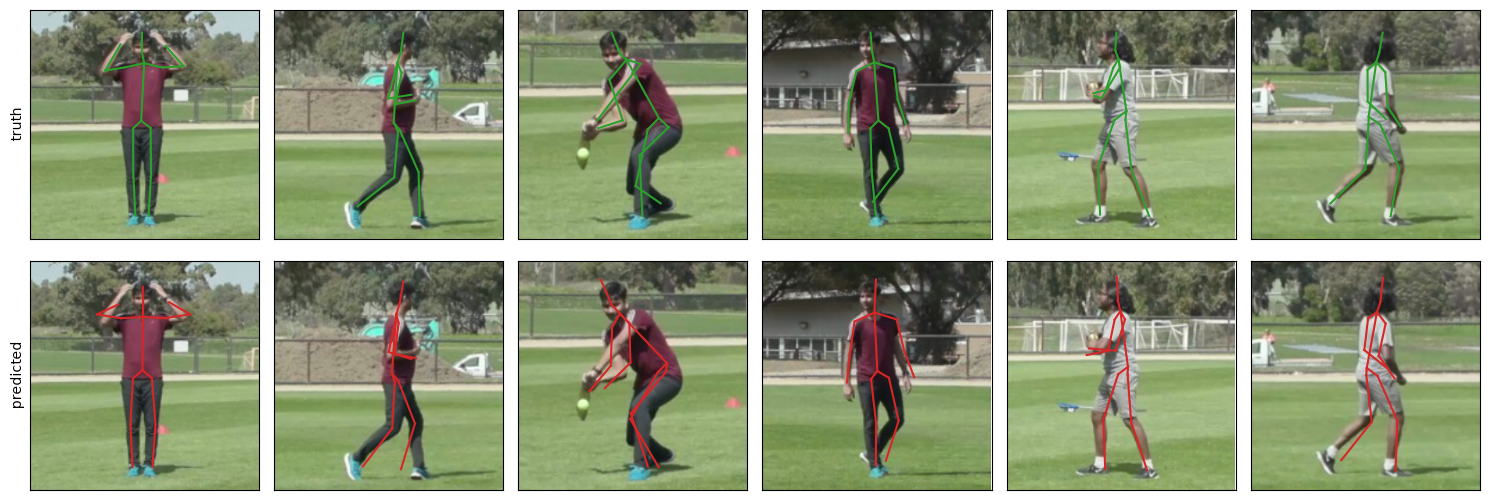

In [7]:
picks = np.linspace(0, len(val_data) - 1, 6).astype(int)
figure, axes = plt.subplots(2, 6, figsize=(15, 5.4))
for column, index in enumerate(picks):
    sample = val_data[int(index)]
    one = {k: v[None] for k, v in sample.items()}
    out = model.predict(net, body, one)

    picture = (sample["image"].numpy().transpose(1, 2, 0) * data.IMAGENET_STD
               + data.IMAGENET_MEAN).clip(0, 1)
    for row, (points, colour, title) in enumerate((
            (sample["truth"].numpy(), "tab:green", "truth"),
            (out["joints"][0].numpy(), "tab:red", "predicted"))):
        uv = to_crop_pixels(points, sample["box"].numpy(), sample["intrinsics"].numpy())
        ax = axes[row, column]
        ax.imshow(picture)
        for a, b in LINKS:
            ax.plot(uv[[a, b], 0], uv[[a, b], 1], "-", color=colour, lw=1.5)
        ax.set(xticks=[], yticks=[], xlim=(0, 256), ylim=(256, 0))
        if column == 0:
            ax.set_ylabel(title)
plt.tight_layout()
plt.show()